# Original pulse sequence
The pulse sequence develop to induce trapping of the ion in the motional ground state is as follows:
1. RF dipolar pulse of the form
$$
H_{RF} = i\frac{RF\_strength}{2} (a - a^{\dagger})
$$
with a duration $\eta/RF\_strength$
2. Y(π/2) pulse on the spin
$$
H_{Y} = \frac{\Delta}{2}\sigma_{z} + \nu aa^{\dagger} + \frac{i\Omega_{y}}{2} [\sigma^{+}D(i\eta) - \sigma^{-}D^{\dagger}(i\eta)]
$$
with a duration of $\pi/(2*\Omega_{y})$
3. X pulse on the spin:
$$
H_{X} = \frac{\Delta}{2}\sigma_{z} + \nu aa^{\dagger} + \frac{i\Omega}{2}[\sigma^{+}D(i\eta) - \sigma^{-}D^{\dagger}(i\eta)]
$$
which is applied for a time $\tau = \frac{\pi}{\eta \Omega}$
4. Undo the Y(π/2) pulse with a Y(-π/2) pulse
5. Undo the RF dipolar pulse with a RF dipolar pulse of opposite sign
6. Dissipation on the spin to reset it to the ground state

In principle, this sequence creates a situation where the effective Hamiltonian is:
$$
H_{eff} = R_{y}PHP^{\dagger}R_{y}^{\dagger} \approx \frac{i\eta\nu}{2} (a^{\dagger}\sigma^{-} - a\sigma^{+}) 
$$

Pulse duration tau: 62.83185307179586


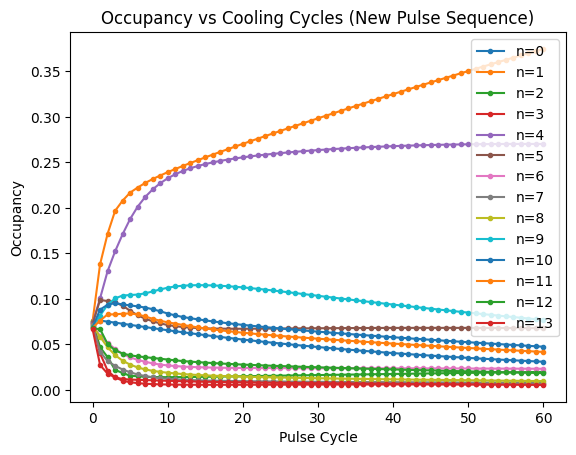

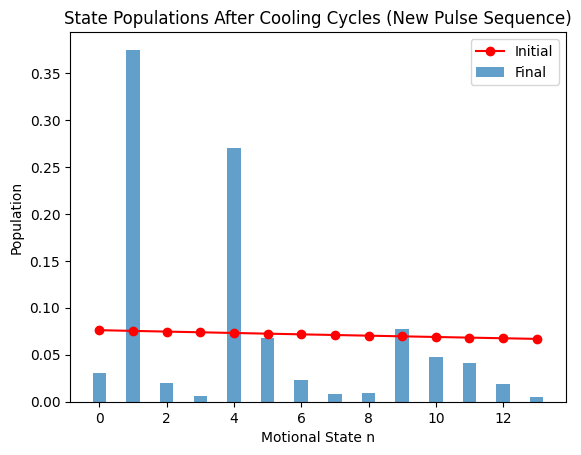

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Define system parameters
Delta = 0  # Detuning
RF_strength = 1  # RF dipolar coupling strength
nu = 1.0     # Motional frequency
Omega = nu  # Rabi frequency
Omega_y = 1000  # Rabi frequency for Y pulse
eta = 0.1   # Lamb-Dicke parameter
n_thermal = 1  # Average thermal phonon number
n0 = 1
gamma = 1000  # Spin relaxation
kT = 100      # Boltzmann constant times temperature
tau =  2*np.pi / (eta * Omega * np.sqrt(n0))  # Pulse duration
print(f"Pulse duration tau: {tau}")
# Define operators
N = 14  # Truncation for the Fock space

# QHO operators
a = destroy(N)  # Annihilation operator
a_dag = a.dag()  # Creation operator
xop = a + a_dag  # Position operator

# Spin operators
sz = sigmaz()
s_plus = sigmap()
s_minus = sigmam()
s_y = sigmay()
s_x = sigmax()

# Full size operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(s_plus, qeye(N))
s_minus_full = tensor(s_minus, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
s_minus_full = tensor(s_minus, qeye(N))
s_x_full = tensor(s_x, qeye(N))

# Displaced Hamiltonian operator
D_op = tensor(qeye(2), displace(N,1j*eta))

"""Hamiltonians for pulse and dissipation steps defined above."""

# Hamiltonian (Free evolution for Dissipation)
H_diss = Delta * s_z_full / 2 + nu * a_dag_full * a_full

# --- Pulses for the new sequence ---

# 1) RF dipolar pulse of i*eta/2
H_rf = (RF_strength / 2) * (a_full + a_dag_full)
rf_duration = eta / RF_strength
L_rf = liouvillian(H_rf, [])
prop_rf = (L_rf * rf_duration).expm()
# undo RF
prop_rf_undo = (-L_rf * rf_duration).expm()
 
# 2) Y(π/2) pulse on the spin, same as H_pulse but with phase shift on the sigmas
H_y = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
          0.5 * Omega_y *(-1j * s_plus_full * D_op + 1j * s_minus_full * D_op.dag())
# H_y = 0.5 * Omega_y *s_y_full
y_duration = np.pi / (2 *Omega_y)
L_y = liouvillian(H_y, [])
prop_y = (L_y * y_duration).expm()
# Undo Y(π/2)
L_y_undo = liouvillian(-H_y, [])
prop_y_undo = (L_y_undo * y_duration).expm()
 
 
# 3) X(τ) pulse on the spin, same as H_pulse but with different phase
#H_x = 0.5 * Delta * s_z_full + nu * a_dag_full * a_full + \
#          0.5 * Omega * (s_plus_full * D_op + s_minus_full * D_op.dag())
H_x = 0.5 * nu * s_x_full + nu * a_dag_full * a_full + \
          0.5 * 1j * Omega * eta * s_z_full * (a_dag_full - a_full)
L_x = liouvillian(H_x, [])
prop_x = (L_x * tau).expm()

# --- Collapse Operators for Dissipation with recoil ---
cosmax = 100
cosal = np.arange(-cosmax, cosmax + 1) / cosmax
W = 3 * (cosal**2 + 1) / 4 * 1 / (2 * cosmax)
W = W / np.sum(W)
G = gamma / 2  # This is Γ/2 in the master equation
tg = 2 / G  # Dissipation duration adjusted for rates
c_ops = []
for i, c in enumerate(cosal):
    U_mot = (1j * c * eta * xop).expm()
    U_full = tensor(qeye(2), U_mot)
    c_ops.append(np.sqrt(G * W[i]) * (s_minus_full * U_full))

# Add sigma_minus decay without recoil (optional, for comparison)
c_ops.append(np.sqrt(gamma) * s_minus_full)

# --- Liouvillian and propagator for dissipation step ---
L_diss = liouvillian(H_diss, c_ops)
prop_diss = (L_diss * tg).expm()

# Combined Propagator for one cooling cycle:
## RF dipolar pulse -> Y(π/2) -> X(τ) -> undo Y -> relaxation -> undo RF
prop_cycle = prop_diss * prop_rf_undo * prop_y_undo * prop_x * prop_y * prop_rf

# --- Simulation ---
num_pulses = 60  # Number of cycles
times_sim = np.arange(num_pulses + 1)  # Integer steps for cycles

# Initial state: spin in ground, motion thermal
thermal_state = (- nu * a_dag * a / kT).expm()
thermal_state = thermal_state / thermal_state.tr()
ground_state = basis(2, 1)
initial_state = tensor(ground_state * ground_state.dag(), thermal_state)

# Storage
occupancies = np.zeros((num_pulses + 1, N))
rho_vec = operator_to_vector(initial_state)

# Initial occupancy
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real

# Evolve step-by-step under the new pulse sequence
current_rho_vec = rho_vec
for k in range(1, num_pulses + 1):
    current_rho_vec = prop_cycle * current_rho_vec

    # Store
    rho_mat = vector_to_operator(current_rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real


# Plot the occupancy of all motional states over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Pulse Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Bar plot
p_motional_initial = occupancies[0, :]
p_motional_final = occupancies[-1, :]
plt.figure()
plt.plot(np.arange(N), p_motional_initial, 'o-', label='Initial' , color='red')
plt.bar(np.arange(N), p_motional_final, width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Cooling Cycles (New Pulse Sequence)')
plt.legend()
plt.show()

# Replicating Machnes paper results
## 1. Ideal pulse sequence.
First, the paper describes an ideal pulse sequence. Assuming $\eta\Omega \gg \nu$ and ignoring the free evolution for the duration of the pulses, the trotter cycle described in Machnes et al. consists of the following steps:
* $X\sigma_{y}$ pulse for dt
 $$
 H_{X\sigma_{y}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$
* Free evolution for dt
 $$
 H_{free} = \nu (a^{\dagger}a + \frac{1}{2})
 $$
 * $-X\sigma_{y}$ pulse for dt
 $$
    H_{-X\sigma_{y}} = -\eta \Omega_T (a + a^{\dagger}) \sigma_{y}
$$ 
* $X\sigma_{x}$ pulse for dt
 $$
 H_{X\sigma_{x}} = \eta \Omega_T (a + a^{\dagger}) \sigma_{x}
$$


Using constraints -> dt_sxx: 0.013211, dt_syx: 0.000132 (tau_free=0.1)
Initial <n>: 9.1677, Final <n>: 7.2141


Using constraints -> dt_sxx: 0.013211, dt_syx: 0.000132 (tau_free=0.1)
Initial <n>: 9.1677, Final <n>: 7.2141


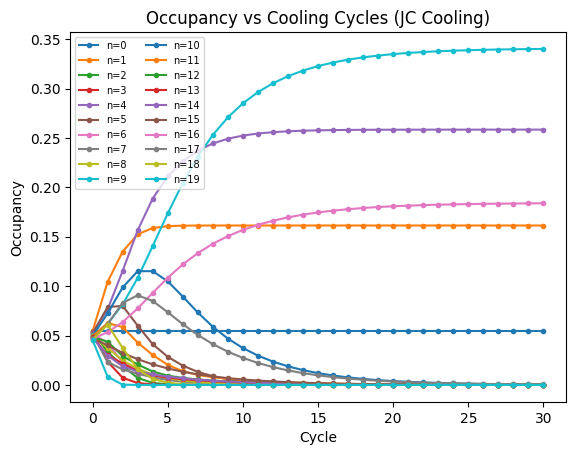

Using constraints -> dt_sxx: 0.013211, dt_syx: 0.000132 (tau_free=0.1)
Initial <n>: 9.1677, Final <n>: 7.2141


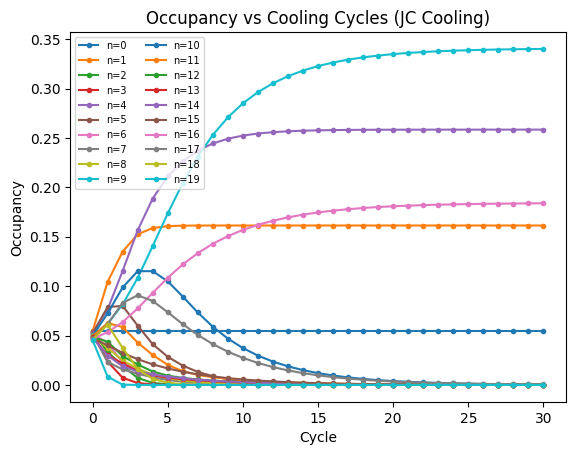

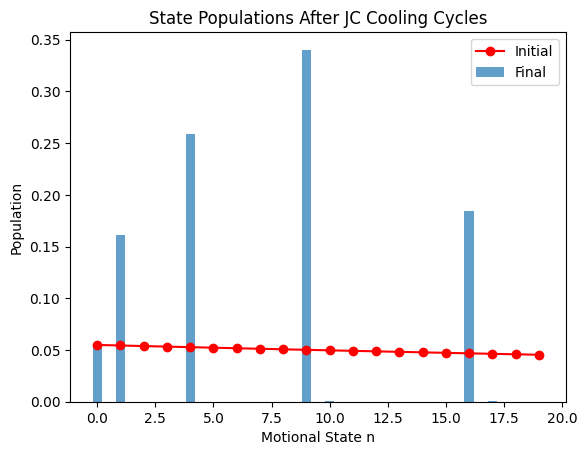

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
Delta = 0            # Spin detuning (set to resonance)
nu = 1.0             # Motional frequency
kT = 100             # Boltzmann constant times temperature
eta = 0.2            # Lamb-Dicke parameter
N = 20               # Fock space truncation
Omega_T = 1000       # Coupling strength used in JC term
gamma = 4            # Spin relaxation rate
n_thermal = 3        # Initial thermal phonon number
num_cycles = 30      # Number of cooling cycles

# Additional system parameters
n_thermal = 1  # Average thermal phonon number
n0 = 1         # Trap center 
# Central pulse duration for JC step
tau =  2*np.pi / (eta * Omega_T * np.sqrt(n0))

# Trotter parameters
Omega_syX = 1000 # Drive strength for sy X pulse
Omega_sxX = 1000 # Drive strength for sx X pulse
n_trotter = 180
# Explicit per-step free evolution time (can be tuned)
tau_free = 0.1

# Enforce constraints:
# 1) tau = n_trotter * (dt_sxx**2) -> dt_sxx = sqrt(tau / n_trotter)
# 2) dt_syX = dt_sxx / (Omega_T * tau_free)
dt_sxx = np.sqrt(tau / (n_trotter))
dt_syx = dt_sxx / (Omega_T * tau_free)
print(f"Using constraints -> dt_sxx: {dt_sxx:.6f}, dt_syx: {dt_syx:.6f} (tau_free={tau_free})")

# Operators
a = destroy(N)
a_dag = a.dag()
sz = sigmaz()
sp = sigmap()
sm = sigmam()
s_x = sigmax()
s_y = sigmay()

# Full-space operators
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
sz_full = tensor(sz, qeye(N))
sp_full = tensor(sp, qeye(N))
sm_full = tensor(sm, qeye(N))
s_x_full = tensor(s_x, qeye(N))
s_y_full = tensor(s_y, qeye(N))

# JC Hamiltonian (red sideband)
H_JC = nu * a_dag_full * a_full + 0.5 * eta * Omega_T * (sp_full * a_full + sm_full * a_dag_full)

# JC evolution: choose π-pulse time on red sideband
L_JC = liouvillian(H_JC, [])
U_JC = (L_JC * tau).expm()

# Spin relaxation to reset internal state
t_relax = 2.0 / gamma
c_op = np.sqrt(gamma * (1 + n0)) * sm_full
L_relax = liouvillian(0 * sz_full, [c_op])
U_relax = (L_relax * t_relax).expm()

# One cooling cycle: JC → relax
prop_cycle = U_relax * U_JC

# Initial state: spin |↓⟩, motion thermal
rho_mot = (- nu * a_dag * a / kT).expm()
rho_mot = rho_mot / rho_mot.tr()
rho_spin_g = basis(2, 1)
rho0 = tensor(rho_spin_g * rho_spin_g.dag(), rho_mot)

# Storage
times_sim = np.arange(num_cycles + 1)
occupancies = np.zeros((num_cycles + 1, N))
n_avg_list = []

# Initial
rho_vec = operator_to_vector(rho0)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real
n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

# Evolve
for k in range(1, num_cycles + 1):
    rho_vec = prop_cycle * rho_vec
    rho_mat = vector_to_operator(rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real
    n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

print(f"Initial <n>: {n_avg_list[0]:.4f}, Final <n>: {n_avg_list[-1]:.4f}")

# Plot motional populations over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Cooling Cycles (JC Cooling)')
plt.legend(ncol=2, fontsize=7)
plt.show()

# Bar plot initial vs final
plt.figure()
plt.plot(np.arange(N), occupancies[0, :], 'o-', label='Initial', color='red')
plt.bar(np.arange(N), occupancies[-1, :], width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After JC Cooling Cycles')
plt.legend()
plt.show()

### Javier pulse durations

Total trotter duration: 0.062832 (tau=0.062832)


Initial <n>: 9.1677, Final <n>: 9.6216


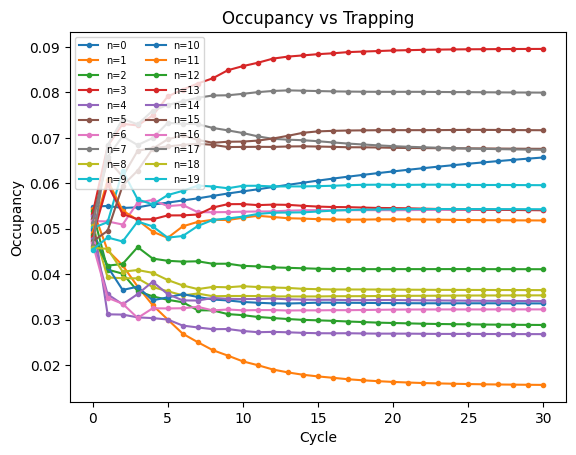

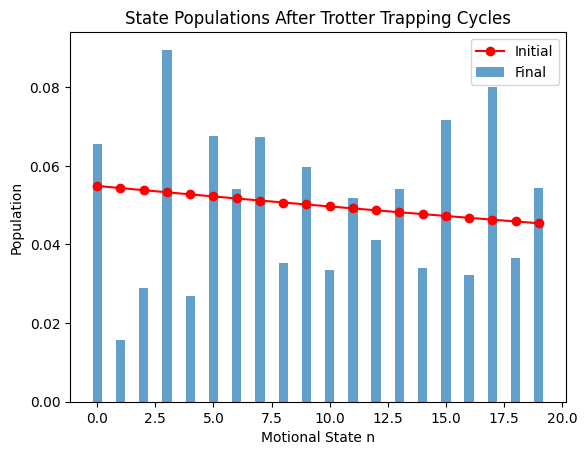

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
Delta = 0            # Spin detuning (set to resonance)
nu = 1.0             # Motional frequency
kT = 100             # Boltzmann constant times temperature
eta = 0.1            # Lamb-Dicke parameter
N = 20               # Fock space truncation
Omega_T = 1000       # Coupling strength used in JC term
gamma = 2            # Spin relaxation rate
n_thermal = 3        # Initial thermal phonon number
num_cycles = 30      # Number of cooling cycles

# Additional system parameters
n_thermal = 1  # Average thermal phonon number
n0 = 1         # Trap center 
# Central pulse duration for JC step
tau =  2*np.pi / (eta * Omega_T * np.sqrt(n0))
# Trotter parameters
n_trotter = 180
# tau= N_trotter *dt_sxx*2
dt_sxx = tau / (2*n_trotter)
dt_syx = tau / (Omega_T * dt_sxx)
tau_free = (tau - 2 * dt_syx - dt_sxx)
print(f"Total trotter duration: {2*dt_syx + dt_sxx  + tau_free:.6f} (tau={tau:.6f})")
dt_block = 2 * np.pi / (Omega_T * n_trotter)

# Operators
a = destroy(N)
a_dag = a.dag()
sz = sigmaz()
sp = sigmap()
sm = sigmam()
s_x = sigmax()
s_y = sigmay()

# Full-space operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(sp, qeye(N))
s_minus_full = tensor(sm, qeye(N))
s_x_full = tensor(s_x, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)

"""Trotter pulse sequence Hamiltonians"""

# 1) X sy pulse Hamiltonian
H_Y = eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y = liouvillian(H_Y)
U_Y = (L_Y * dt_syx).expm()

# 2) Free evolution Hamiltonian
H_free = nu * (a_dag_full * a_full + 1/2)
L_free = liouvillian(H_free)
U_free = (L_free * tau_free).expm()

# 3) X -sy pulse Hamiltonian
H_Y_undo = -eta * Omega_T * (a_full + a_dag_full) * s_y_full
L_Y_undo = liouvillian(H_Y_undo)
U_Y_undo = (L_Y_undo * dt_syx).expm()

# 4) Another X sx pulse Hamiltonian
H_X_sx = eta * Omega_T * (a_full + a_dag_full) * s_x_full
L_X_sx = liouvillian(H_X_sx)
U_X_sx = (L_X_sx * dt_sxx).expm()

# 5) Relaxation step
t_relax = 2.0 / gamma
c_op = np.sqrt(gamma * (1 + n0)) * s_minus_full
L_relax = liouvillian(0 * s_z_full, [c_op])
U_relax = (L_relax * t_relax).expm()    

prop_trotter = U_Y_undo * U_free * U_Y * U_X_sx
prop_cycle_trotter = U_relax * (prop_trotter**n_trotter)

# Initial state: spin |↓>, motion thermal
rho_mot = (- nu * a_dag * a / kT).expm()
rho_mot = rho_mot / rho_mot.tr()
rho_spin_g = basis(2, 1)
rho0 = tensor(rho_spin_g * rho_spin_g.dag(), rho_mot)
rho0_vec = operator_to_vector(rho0)


# Storage
times_sim = np.arange(num_cycles + 1)
occupancies = np.zeros((num_cycles + 1, N))
n_avg_list = []

# Initial
rho_vec = operator_to_vector(rho0)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real
n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

# Evolve
for k in range(1, num_cycles + 1):
    rho_vec = prop_cycle_trotter * rho_vec
    rho_mat = vector_to_operator(rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real
    n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

print(f"Initial <n>: {n_avg_list[0]:.4f}, Final <n>: {n_avg_list[-1]:.4f}")

# Plot motional populations over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Trapping')
plt.legend(ncol=2, fontsize=7)
plt.show()

# Bar plot initial vs final
plt.figure()
plt.plot(np.arange(N), occupancies[0, :], 'o-', label='Initial', color='red')
plt.bar(np.arange(N), occupancies[-1, :], width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Trotter Trapping Cycles')
plt.legend()
plt.show()

### Gonzalo version pulse durations

Pulse duration tau: 0.06283185307179587
Using dt_free=0.004712
Using dt_sxx=0.003142
Using dt_syx=0.006667
Initial <n>: 9.1677, Final <n>: 9.3850


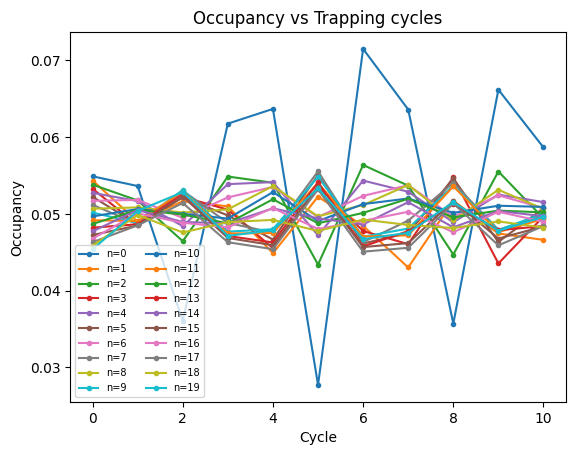

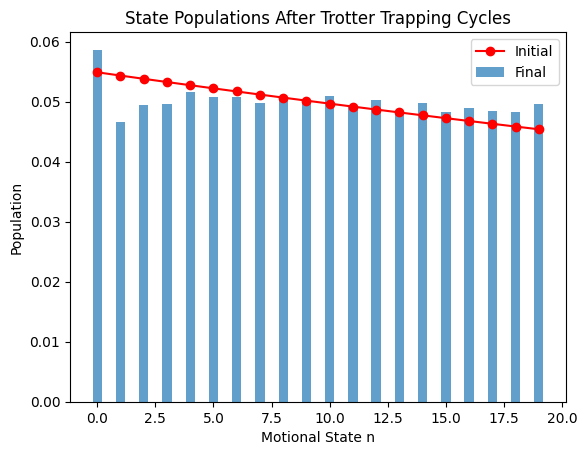

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
Delta = 0            # Spin detuning (set to resonance)
nu = 1.0             # Motional frequency
kT = 100             # Boltzmann constant times temperature
eta = 0.1            # Lamb-Dicke parameter
N = 20               # Fock space truncation
Omega = 1000
Omega_syx = 100000
Omega_sxx = 1000
gamma = 2            # Spin relaxation rate
n_thermal = 3        # Initial thermal phonon number
num_cycles = 10      # Number of cooling cycles

# Additional system parameters
n_thermal = 1  # Average thermal phonon number
n0 = 1         # Trap center 
# Central pulse duration for JC step
n_trotter = 10
tau =  2*np.pi / (eta * Omega * np.sqrt(n0))
print(f"Pulse duration tau: {tau}")
dt_sxx = tau / (2*n_trotter)
dt_free = dt_sxx * 1.5 # try similar order of magnitude as pulse durations
dt_syx = (dt_sxx*Omega_sxx)/(Omega_syx*dt_free)
print(f"Using dt_free={dt_free:.6f}")
print(f"Using dt_sxx={dt_sxx:.6f}")
print(f"Using dt_syx={dt_syx:.6f}")

# Operators
a = destroy(N)
a_dag = a.dag()
sz = sigmaz()
sp = sigmap()
sm = sigmam()
s_x = sigmax()
s_y = sigmay()

# Full-space operators
s_z_full = tensor(sz, qeye(N))
s_plus_full = tensor(sp, qeye(N))
s_minus_full = tensor(sm, qeye(N))
s_x_full = tensor(s_x, qeye(N))
s_y_full = tensor(s_y, qeye(N))
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)

"""Trotter pulse sequence Hamiltonians"""

# 1) X sy pulse Hamiltonian
H_Y = eta * Omega_syx * (a_full + a_dag_full) * s_y_full
L_Y = liouvillian(H_Y)
U_Y = (L_Y * dt_syx).expm()

# 2) Free evolution Hamiltonian
H_free = nu * (a_dag_full * a_full + 1/2)
L_free = liouvillian(H_free)
U_free = (L_free * dt_free).expm()

# 3) X -sy pulse Hamiltonian
H_Y_undo = -eta * Omega_syx * (a_full + a_dag_full) * s_y_full
L_Y_undo = liouvillian(H_Y_undo)
U_Y_undo = (L_Y_undo * dt_syx).expm()

# 4) Another X sx pulse Hamiltonian
H_X_sx = eta * Omega_sxx * (a_full + a_dag_full) * s_x_full
L_X_sx = liouvillian(H_X_sx)
U_X_sx = (L_X_sx * dt_sxx).expm()

# 5) Relaxation step
t_relax = 2.0 / gamma
c_op = np.sqrt(gamma * (1 + n0)) * s_minus_full
L_relax = liouvillian(0 * s_z_full, [c_op])
U_relax = (L_relax * t_relax).expm()    

# prop_trotter = U_X_sx * U_Y_undo * U_free * U_Y
prop_trotter = U_Y_undo * U_free * U_Y
prop_cycle_trotter = (prop_trotter**n_trotter)

# Initial state: spin |↓>, motion thermal
rho_mot = (- nu * a_dag * a / kT).expm()
rho_mot = rho_mot / rho_mot.tr()
rho_spin_g = basis(2, 1)
rho0 = tensor(rho_spin_g * rho_spin_g.dag(), rho_mot)
rho0_vec = operator_to_vector(rho0)


# Storage
times_sim = np.arange(num_cycles + 1)
occupancies = np.zeros((num_cycles + 1, N))
n_avg_list = []

# Initial
rho_vec = operator_to_vector(rho0)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real
n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

# Evolve
for k in range(1, num_cycles + 1):
    rho_vec = prop_cycle_trotter * rho_vec
    rho_mat = vector_to_operator(rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real
    n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

print(f"Initial <n>: {n_avg_list[0]:.4f}, Final <n>: {n_avg_list[-1]:.4f}")

# Plot motional populations over cycles
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs Trapping cycles')
plt.legend(ncol=2, fontsize=7)
plt.show()

# Bar plot initial vs final
plt.figure()
plt.plot(np.arange(N), occupancies[0, :], 'o-', label='Initial', color='red')
plt.bar(np.arange(N), occupancies[-1, :], width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional State n')
plt.ylabel('Population')
plt.title('State Populations After Trotter Trapping Cycles')
plt.legend()
plt.show()

In [22]:
import numpy as np
from qutip import *

# --- parameters ---
N = 10
eta = 0.1
Omega = 100.0
nu = 1.0

dt_syx = 0.003
tau_free = 0.05

# --- operators ---
a = destroy(N)
adag = a.dag()

sx = sigmax()
sy = sigmay()

a_f = tensor(qeye(2), a)
adag_f = tensor(qeye(2), adag)
sy_f = tensor(sy, qeye(N))

# --- Hamiltonians ---
H = nu * a_dag_full * a_full + 0.5 * eta * Omega_T * (sp_full * a_full + sm_full * a_dag_full)

# --- unitaries ---
U_JC = (-1j * H * tau).expm()

# principal matrix logarithm
G = 1j * U_JC.logm()

Heff_target = sy_f * (a_f - adag_f)

# Hilbert-Schmidt inner product
def overlap(A, B):
    return (A.dag() * B).tr()

coeff = overlap(Heff_target, G) / overlap(Heff_target, Heff_target)

print("Effective prefactor:", np.real(coeff))

t_eff_theory = nu * eta * Omega * dt_syx * tau_free

print("Numerical t_eff:", np.real(coeff))
print("Theory t_eff:   ", t_eff_theory)

Heff_error = sy_f * (a_f + adag_f)
print("Error overlap:", np.abs(overlap(Heff_error, G)))


Effective prefactor: 3.773904790443655e-17
Numerical t_eff: 3.773904790443655e-17
Theory t_eff:    0.0015
Error overlap: 6.1876426389880784e-15


In [ ]:
import numpy as np
from qutip import *

# --- Parameters for the minimal Xσ_y – wait – Xσ_y block ---
N = 20          # Fock space truncation
nu = 1.0        # Motional frequency
eta = 0.1      # Lamb–Dicke-like factor
Omega_T = 50.0  # Coupling strength F = eta * Omega_T
dt_syx = 0.01   # Duration of the Xσ_y pulses
tau_free = 0.2  # Free evolution time between the pulses

F = eta * Omega_T

# --- Oscillator and spin operators ---
a = destroy(N)
adag = a.dag()

# Quadratures (no sqrt(2) factors, so [X, P] = 2i)
X = a + adag
P = 1j * (adag - a)

sx = sigmax()
sy = sigmay()
sz = sigmaz()

# Full-space operators
X_full = tensor(qeye(2), X)
P_full = tensor(qeye(2), P)
a_full = tensor(qeye(2), a)
adag_full = tensor(qeye(2), adag)
sy_full = tensor(sy, qeye(N))

# Hamiltonians
H_Xsy = F * (a_full + adag_full) * sy_full
H_free = nu * adag_full * a_full

# Unitaries for the three-step block
U_Y = (-1j * H_Xsy * dt_syx).expm()          # Xσ_y pulse
U_free = (-1j * H_free * tau_free).expm()   # free evolution
U_Y_undo = (-1j * (-H_Xsy) * dt_syx).expm() # -Xσ_y pulse

U_block = U_Y_undo * U_free * U_Y

# --- Initial state: spin in +y eigenstate, motional coherent state ---
# up = basis(2, 0)
down = basis(2, 1)

alpha = 1.0  # coherent state amplitude
psi_mot = coherent(N, alpha)

psi0 = tensor(down, psi_mot)
rho0 = psi0 * psi0.dag()

# Expectation values before
X0 = expect(X_full, rho0)
P0 = expect(P_full, rho0)

# Apply one Xσ_y – wait – Xσ_y block
rho1 = U_block * rho0 * U_block.dag()

X1 = expect(X_full, rho1)
P1 = expect(P_full, rho1)

# Theoretical leading-order prediction:
# H_eff,int ≈ F * nu * dt_syx * σ_y P  with [X, P] = 2i  =>  dX/dt = 2 F nu dt_syx σ_y
# For spin in σ_y = +1 eigenstate,
Delta_X_theory = 2 * F * nu * dt_syx * tau_free

print("--- Minimal Xσ_y – wait – Xσ_y test ---")
print(f"<X> initial: {X0:.6f}, <X> final: {X1:.6f}, Δ<X> numeric: {X1 - X0:.6f}")
print(f"<P> initial: {P0:.6f}, <P> final: {P1:.6f}, Δ<P> numeric: {P1 - P0:.6f}")
print(f"Expected leading-order Δ<X> (theory): {Delta_X_theory:.6f}")

--- Minimal Xσ_y – wait – Xσ_y test ---
<X> initial: 2.000000, <X> final: 1.960133, Δ<X> numeric: -0.039867
<P> initial: 0.000000, <P> final: -0.397339, Δ<P> numeric: -0.397339
Expected leading-order Δ<X> (theory): 0.020000


Total target JC time tau = 6.283185e+00
Using n_trotter=20, dt_sy=3.142e-01, t_free=1.000e+01
Initial <n>: 9.1677, Final <n>: 8.7150


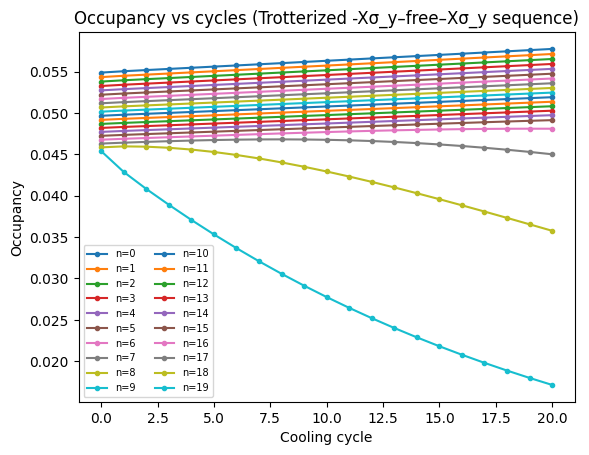

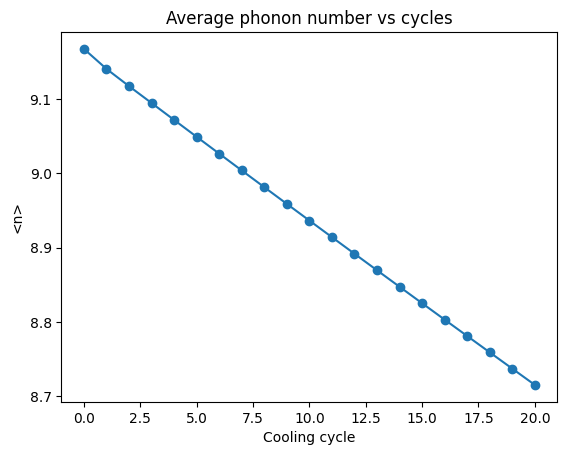

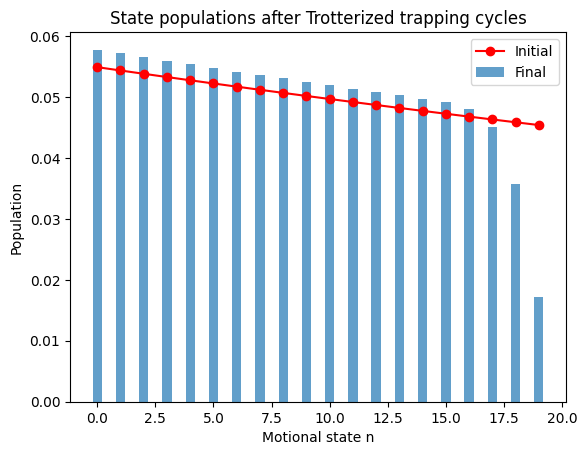

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# --- Parameters (close to earlier JC example) ---
Delta = 0.0          # Spin detuning
nu = 1.0             # Motional frequency
kT = 100.0           # Temperature scale
eta = 0.01            # Lamb–Dicke parameter
N = 20               # Fock space truncation
Omega = 100.0       # Rabi frequency for JC-like coupling
Omega_T = 10     # Coupling strength in H_{Xσ_y}
gamma = 4.0          # Spin relaxation rate
n0 = 1.0             # Trap center (for tau definition)
num_cycles = 20      # Number of cooling cycles to simulate
n_trotter = 20      # Number of Trotter blocks within total time tau

# Total effective JC pulse time tau, as before
tau = 2 * np.pi / (eta * Omega * np.sqrt(n0))
print(f"Total target JC time tau = {tau:.6e}")

# Choose dt_sy and t_free so that n_trotter * (2*dt_sy + t_free) = tau

t_free = 10
dt_sy = 2 * np.pi / (t_free * eta * n_trotter * Omega_T)


print(f"Using n_trotter={n_trotter}, dt_sy={dt_sy:.3e}, t_free={t_free:.3e}")
assert t_free > 0, "t_free must be positive; adjust n_trotter or dt_sy choice."

# --- Operators ---
a = destroy(N)
a_dag = a.dag()
sz = sigmaz()
sp = sigmap()
sm = sigmam()
s_y = sigmay()

# Full-space operators
a_full = tensor(qeye(2), a)
a_dag_full = tensor(qeye(2), a_dag)
sz_full = tensor(sz, qeye(N))
s_y_full = tensor(s_y, qeye(N))
s_minus_full = tensor(sm, qeye(N))

# Free Hamiltonian (for the Trotter block)
H_free = nu * (a_dag_full * a_full - 0.5*s_z_full)

# Xσ_y Hamiltonian
H_Xsy = eta * Omega_T * (a_full + a_dag_full) * s_y_full

# Liouvillians for the Trotter block
L_Y = liouvillian(H_Xsy, [])
L_Y_undo = liouvillian(-H_Xsy, [])
L_free = liouvillian(H_free, [])

U_Y = (L_Y * dt_sy).expm()              
U_free = (L_free * t_free).expm()       # free evolution
U_Y_undo = (L_Y_undo * dt_sy).expm()    # opposite-sign Xσ_y pulse

# One Trotter block over duration 2*dt_sy + t_free
U_trotter_block = U_Y_undo * U_free * U_Y  

# --- Spin relaxation (reset) step ---
t_relax = 2.0 / gamma
c_op = np.sqrt(gamma * (1.0 + n0)) * s_minus_full
L_relax = liouvillian(0 * sz_full, [c_op])
U_relax = (L_relax * t_relax).expm()

# --- Full cooling cycle: Trotterized evolution over tau, then relaxation ---
U_trotter_total = U_trotter_block ** n_trotter
U_cycle = U_relax * U_trotter_total

# --- Initial state: spin |↓>, motion thermal ---
rho_mot = (- nu * a_dag * a / kT).expm()
rho_mot = rho_mot / rho_mot.tr()
rho_spin_g = basis(2, 1)
rho0 = tensor(rho_spin_g * rho_spin_g.dag(), rho_mot)

# Storage
times_sim = np.arange(num_cycles + 1)
occupancies = np.zeros((num_cycles + 1, N))
n_avg_list = []

rho_vec = operator_to_vector(rho0)
rho_mat = vector_to_operator(rho_vec)
occupancies[0, :] = rho_mat.ptrace(1).diag().real
n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

# --- Evolve over cooling cycles ---
for k in range(1, num_cycles + 1):
    rho_vec = U_cycle * rho_vec
    rho_mat = vector_to_operator(rho_vec)
    occupancies[k, :] = rho_mat.ptrace(1).diag().real
    n_avg_list.append(expect(a_dag_full * a_full, rho_mat))

print(f"Initial <n>: {n_avg_list[0]:.4f}, Final <n>: {n_avg_list[-1]:.4f}")

# --- Plots ---
plt.figure()
for n in range(N):
    plt.plot(times_sim, occupancies[:, n], '.-', label=f'n={n}')
plt.xlabel('Cooling cycle')
plt.ylabel('Occupancy')
plt.title('Occupancy vs cycles (Trotterized -Xσ_y–free–Xσ_y sequence)')
plt.legend(ncol=2, fontsize=7)
plt.show()

plt.figure()
plt.plot(times_sim, n_avg_list, 'o-')
plt.xlabel('Cooling cycle')
plt.ylabel('<n>')
plt.title('Average phonon number vs cycles')
plt.show()

plt.figure()
plt.plot(np.arange(N), occupancies[0, :], 'o-', label='Initial', color='red')
plt.bar(np.arange(N), occupancies[-1, :], width=0.4, label='Final', alpha=0.7)
plt.xlabel('Motional state n')
plt.ylabel('Population')
plt.title('State populations after Trotterized trapping cycles')
plt.legend()
plt.show()